# AI Safety Monitoring - Proof of Concept

This notebook demonstrates three core detection capabilities:
1. **Scene Classification** - Classify images into scene categories (bridge, railway, ship, others)
2. **Scene Segmentation** - Detect and segment hazardous objects in scenes
3. **Human Detection** - Detect and extract human masks from images

In [46]:
# Setup and Configuration
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

# Paths - Updated for local development
project_root = Path(__file__).parent if '__file__' in globals() else Path.cwd()
sys.path.insert(0, str(project_root))

# Configuration
rng_seed = 90
np.random.seed(rng_seed)

print("✓ Environment initialized successfully!")
print(f"✓ Project root: {project_root}")
print(f"✓ Python path updated")

image_path = "data/human_images/suggested-lc7dtAJmDr0WFZhFyLak_jpg.rf.359c55f403e145f05a527bc6ca94838c.jpg"

✓ Environment initialized successfully!
✓ Project root: /Users/weifong.chia/Documents/MSc_AI/courses/Spring/credit/70079-SWE-Group-Project/ai-safety-monitoring
✓ Python path updated


---
# 1. Scene Classification

Classify images into scene categories: **bridge**, **railway**, **ship**, or **others**.

In [47]:
# Load Scene Classification Model
from src.scene_detection.inference import SceneDetector

# Note: Update this path to your actual trained model checkpoint
# If you haven't trained the model yet, you need to run the training script first
checkpoint_path = 'models/best_scene_classifier.pth'  # Update this path as needed

# Check if model exists
if not Path(checkpoint_path).exists():
    print(f"⚠️  Model not found at: {checkpoint_path}")
    print("Please ensure you have trained the scene classification model first.")
    print("Run: python -m src.scene_detection.train")
else:
    detector = SceneDetector(
        checkpoint_path=checkpoint_path,
        device='auto'
    )
    
    print(f"✓ Model loaded on: {detector.device}")
    print(f"✓ Classes: {detector.class_names}")

✓ Model loaded on: mps
✓ Classes: ['bridge', 'others', 'railway', 'ship']


### Run Prediction

Predictions for suggested-lc7dtAJmDr0WFZhFyLak_jpg.rf.359c55f403e145f05a527bc6ca94838c.jpg:
  railway: 1.0000 (100.00%)
  bridge: 0.0000 (0.00%)
  others: 0.0000 (0.00%)


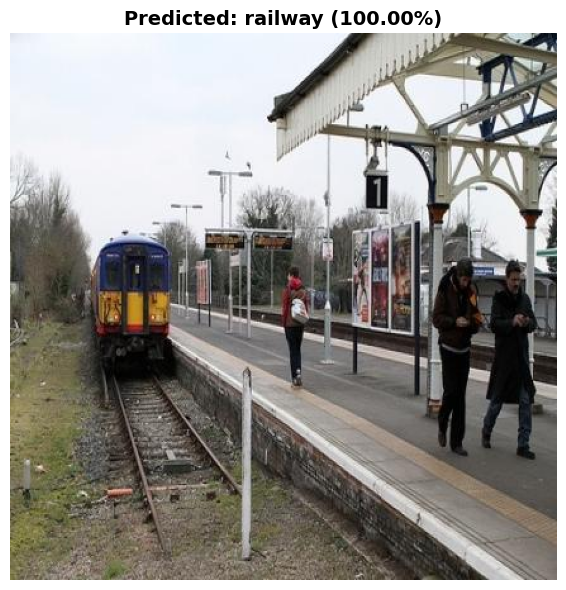

In [48]:
# Predict scene class for a single image
# Get top-3 predictions
scene_predictions = detector.predict(image_path, topk=3)

# Display results
print(f"Predictions for {os.path.basename(image_path)}:")
for label, prob in scene_predictions:
    print(f"  {label}: {prob:.4f} ({prob*100:.2f}%)")

# Visualize
img = Image.open(image_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title(f"Predicted: {scene_predictions[0][0]} ({scene_predictions[0][1]:.2%})", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

---
# 2. Scene Segmentation

Detect and segment hazardous objects in scenes using YOLO.

In [49]:
# Load Scene Segmentation Model
SEGMENTATION_MODELS = {
    "railway": "runs/segment/runs/segment/railway_hazard/weights/best.pt",
    "ship": "runs/segment/runs/segment/ship_hazard/weights/best.pt",
    "bridge": "runs/segment/runs/segment/bridge_hazard/weights/best.pt"
}

# Select scene type
scene_type = scene_predictions[0][0]  # Options: "railway", "ship", "bridge"

# Check if model exists
model_path = SEGMENTATION_MODELS[scene_type]
if not Path(model_path).exists():
    print(f"⚠️  Model not found at: {model_path}")
    print(f"Please ensure you have trained the {scene_type} segmentation model first.")
else:
    model_seg = YOLO(model_path)
    print(f"✓ Loaded {scene_type} segmentation model")
    print(f"✓ Model path: {model_path}")

✓ Loaded railway segmentation model
✓ Model path: runs/segment/runs/segment/railway_hazard/weights/best.pt


### Run Prediction


image 1/1 /Users/weifong.chia/Documents/MSc_AI/courses/Spring/credit/70079-SWE-Group-Project/ai-safety-monitoring/data/human_images/suggested-lc7dtAJmDr0WFZhFyLak_jpg.rf.359c55f403e145f05a527bc6ca94838c.jpg: 640x640 1 rail-raised, 1 tram-track, 2 trackbeds, 73.7ms
Speed: 1.6ms preprocess, 73.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


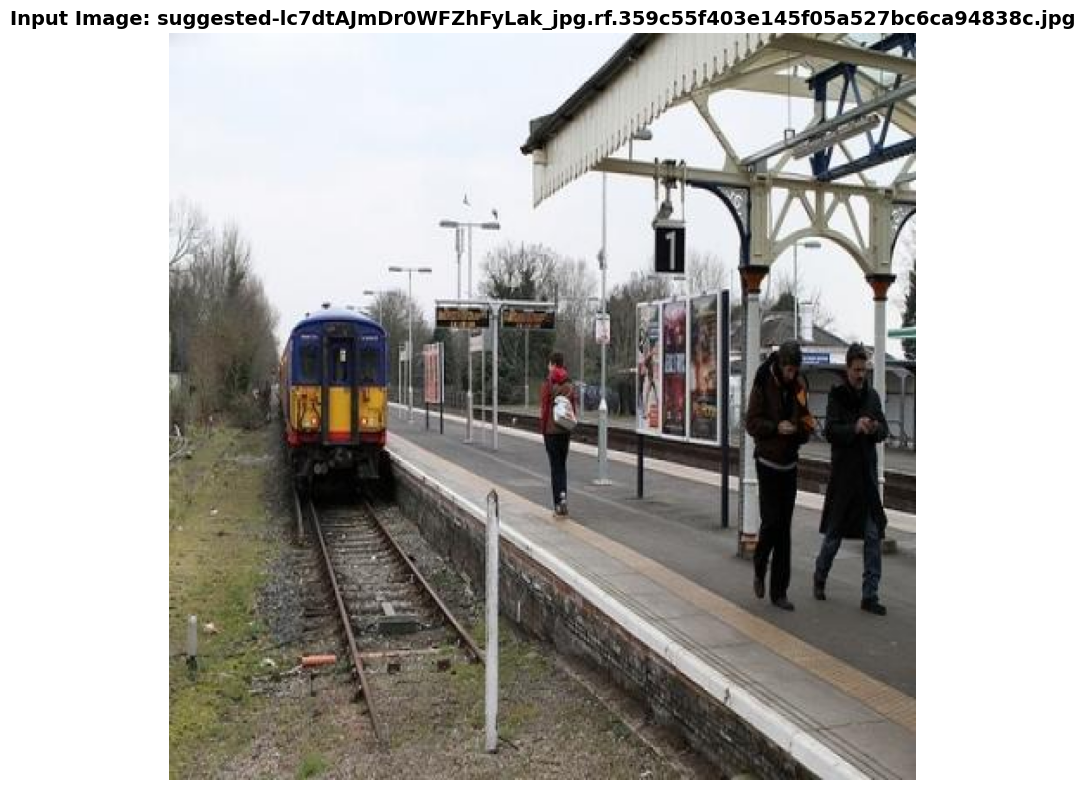

✓ Image processed: suggested-lc7dtAJmDr0WFZhFyLak_jpg.rf.359c55f403e145f05a527bc6ca94838c.jpg
✓ Detected 4 object(s)


In [50]:
# Run segmentation on a single image
# Update this path to an appropriate image based on the scene type
# image_path = 'data/scene_detection_test/rs01242.jpg'  # Example: railway scene

# Run inference
results = model_seg.predict(source=image_path, conf=0.5, save=False)
result = results[0]

# Load original image for display
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display original image
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title(f'Input Image: {Path(image_path).name}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✓ Image processed: {Path(image_path).name}")
print(f"✓ Detected {len(result.masks) if result.masks else 0} object(s)")

### Extract Masks

✓ Extracted 4 mask(s)
✓ Mask shape: (4, 640, 640)


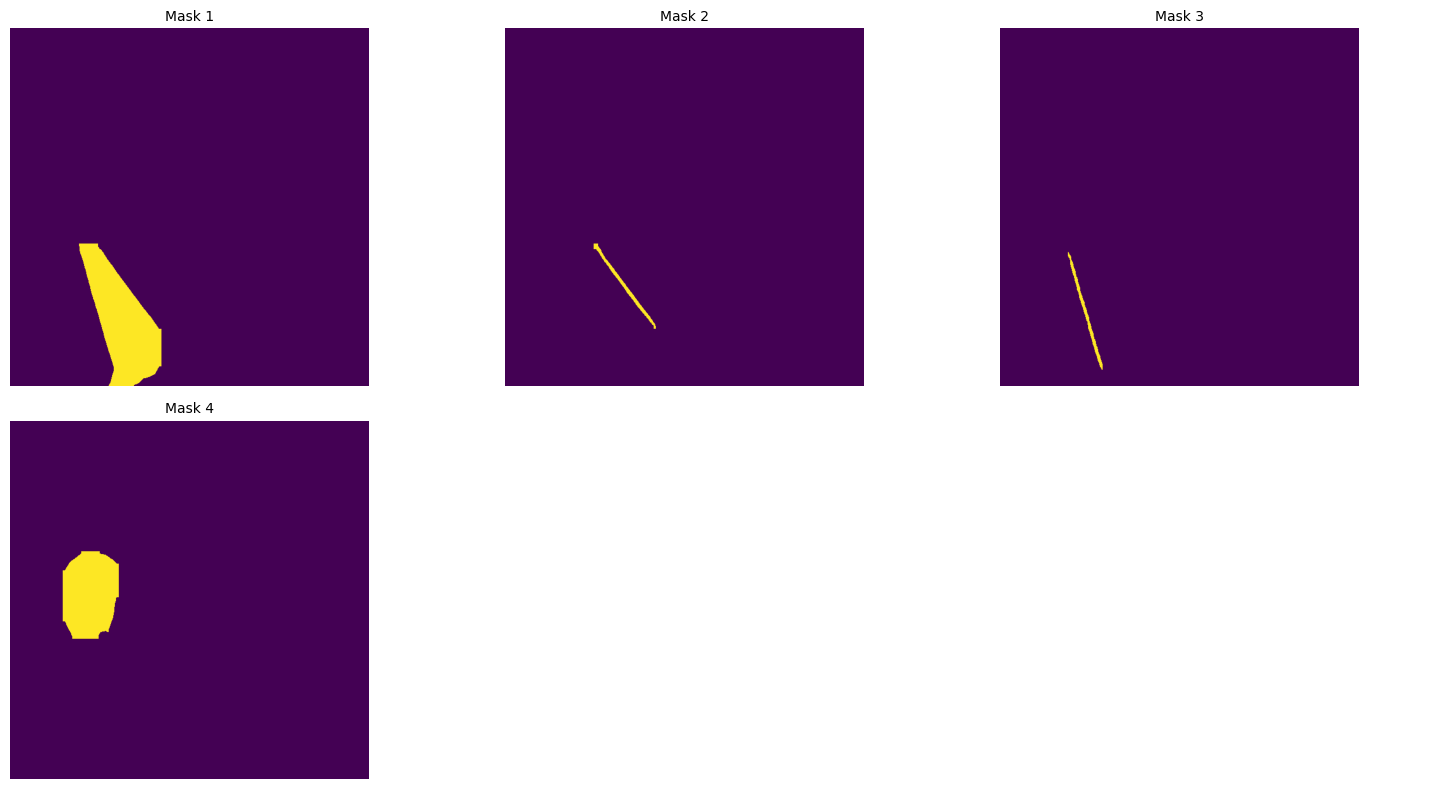


→ Masks stored in 'seg_masks' variable
→ Access: seg_masks[0], seg_masks[1], etc.


In [51]:
# Extract and visualize segmentation masks
if result.masks is not None:
    seg_masks = result.masks.data.cpu().numpy()  # Shape: (num_objects, height, width)
    
    print(f"✓ Extracted {len(seg_masks)} mask(s)")
    print(f"✓ Mask shape: {seg_masks.shape}")
    
    # Visualize masks
    num_masks = len(seg_masks)
    cols = min(3, num_masks)
    rows = (num_masks + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if num_masks == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_masks > 1 else [axes]
    
    for i in range(num_masks):
        mask = seg_masks[i]
        axes[i].imshow(mask, cmap='viridis')
        axes[i].set_title(f'Mask {i+1}', fontsize=10)
        axes[i].axis('off')
    
    for i in range(num_masks, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n→ Masks stored in 'seg_masks' variable")
    print(f"→ Access: seg_masks[0], seg_masks[1], etc.")
else:
    print("No segmentation masks found")
    seg_masks = None


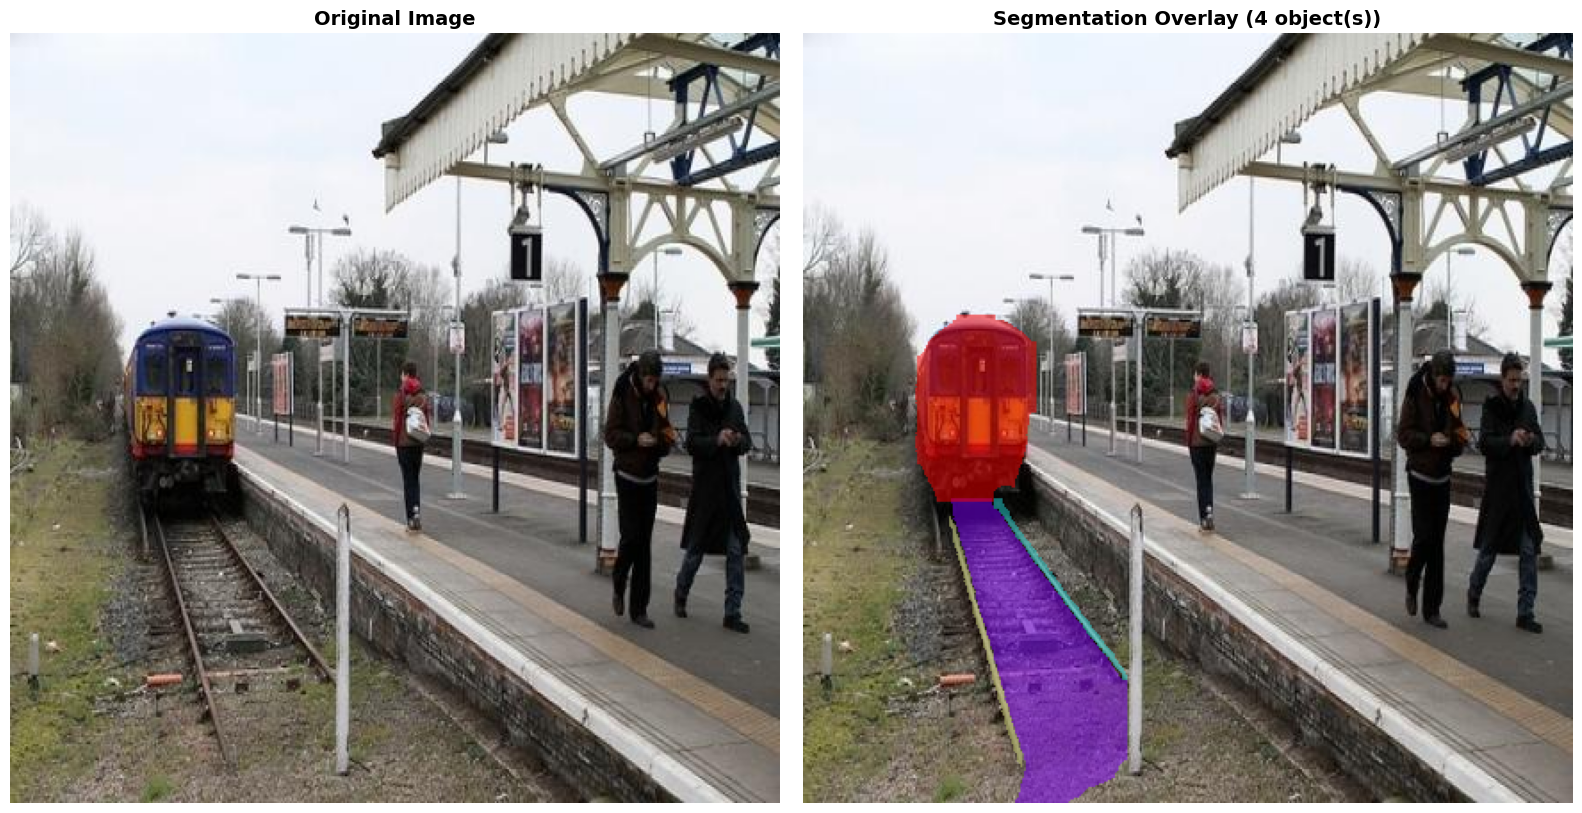

✓ Overlaid 4 mask(s) on original image


In [52]:
# Overlay segmentation masks on the original image
if seg_masks is not None:
    # Create a copy of the original image for overlay
    overlay_img = img_rgb.copy()
    
    # Generate different colors for each mask
    colors = plt.cm.rainbow(np.linspace(0, 1, len(seg_masks)))
    
    # Create composite overlay
    for i, mask in enumerate(seg_masks):
        # Resize mask to match image dimensions if needed
        if mask.shape != img_rgb.shape[:2]:
            mask_resized = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]))
        else:
            mask_resized = mask
        
        # Convert mask to binary (0 or 1)
        mask_binary = (mask_resized > 0.5).astype(bool)
        
        # Apply colored overlay where mask is True
        color_rgb = (np.array(colors[i][:3]) * 255).astype(np.uint8)
        overlay_img[mask_binary] = overlay_img[mask_binary] * 0.5 + color_rgb * 0.5
    
    # Display side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(overlay_img.astype(np.uint8))
    axes[1].set_title(f'Segmentation Overlay ({len(seg_masks)} object(s))', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Overlaid {len(seg_masks)} mask(s) on original image")
else:
    print("No masks to overlay")

### Overlay Masks on Original Image

---
# 3. Human Detection

Detect humans and extract binary masks for further processing.

In [38]:
# Load Human Detection Model
from src.human_detection.detector import HumanDetector

# The HumanDetector uses the model specified in src/human_detection/config.py
# Default model: yolov8m-seg.pt (will be auto-downloaded on first use)
human_detector = HumanDetector()

print("✓ Human detection model loaded")
print("✓ Using HumanDetector class from src/human_detection/detector.py")

Loading YOLO model: yolov8m-seg.pt...
✓ Human detection model loaded
✓ Using HumanDetector class from src/human_detection/detector.py


### Load Human Detection Model

### Run Prediction

In [39]:
# Load image from image_path
frame = cv2.imread(image_path)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Extract binary masks using the HumanDetector class
human_masks = human_detector.get_masks(frame)

print(f"✓ Image loaded: {Path(image_path).name}")
print(f"✓ Extracted {len(human_masks)} person mask(s)")
if human_masks:
    print(f"✓ Mask shape: {human_masks[0].shape}")
    print(f"✓ Mask dtype: {human_masks[0].dtype}")
    print(f"✓ Unique values: {np.unique(human_masks[0])}")  # Should be [0, 1]

✓ Image loaded: suggested-lc7dtAJmDr0WFZhFyLak_jpg.rf.359c55f403e145f05a527bc6ca94838c.jpg
✓ Extracted 3 person mask(s)
✓ Mask shape: (432, 432)
✓ Mask dtype: uint8
✓ Unique values: [0 1]


### Visualize Masks

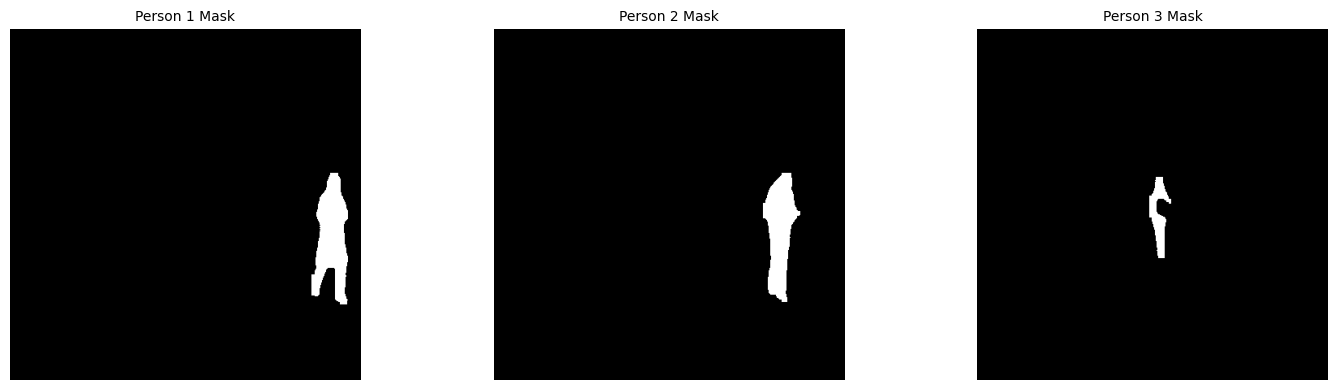


→ Masks stored in 'human_masks' variable
→ Access: human_masks[0], human_masks[1], etc.


In [40]:
# Visualize human masks
if human_masks:
    num_masks = len(human_masks)
    cols = min(3, num_masks)
    rows = (num_masks + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if num_masks == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_masks > 1 else [axes]
    
    for i in range(num_masks):
        mask = human_masks[i]
        axes[i].imshow(mask, cmap='gray')
        axes[i].set_title(f'Person {i+1} Mask', fontsize=10)
        axes[i].axis('off')
    
    for i in range(num_masks, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n→ Masks stored in 'human_masks' variable")
    print(f"→ Access: human_masks[0], human_masks[1], etc.")
else:
    print("No human masks detected")

In [ ]:
# Overlay human masks on the original image
if human_masks:
    # Create a copy of the original image for overlay
    overlay_img = frame_rgb.copy()
    
    # Generate different colors for each person
    colors = plt.cm.Set1(np.linspace(0, 1, len(human_masks)))
    
    # Create composite overlay
    for i, mask in enumerate(human_masks):
        # Apply colored overlay where mask is True
        color_rgb = (np.array(colors[i][:3]) * 255).astype(np.uint8)
        mask_bool = mask.astype(bool)
        overlay_img[mask_bool] = overlay_img[mask_bool] * 0.5 + color_rgb * 0.5
    
    # Display side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(frame_rgb)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(overlay_img.astype(np.uint8))
    axes[1].set_title(f'Human Detection Overlay ({len(human_masks)} person(s))', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Overlaid {len(human_masks)} human mask(s) on original image")
else:
    print("No human masks to overlay")

### Overlay Human Masks on Original Image

# 4. (Placeholder) Human-Hazard Overlap